<a href="https://colab.research.google.com/github/LinkSon-PC/ML-IA-Master/blob/main/Ejercicio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio 2 — Análisis de Datos y Red Neuronal con Prompting

**Módulo: Python para IA** | Máster en Inteligencia Artificial

**Tipo**: Autoevaluable | **Sesión**: 2
**Fecha límite**: Antes de la Sesión 3

---

### Instrucciones

1. **Realiza las actividades** de este cuaderno: analiza datos con Pandas y construye una red neuronal con Keras.
2. Usa **Gemini, Copilot, o cualquier herramienta de IA** para ayudarte.
3. Las celdas de validación te ayudarán a saber si vas bien ✅
4. **Entregable**: Una vez hayas completado las actividades, responde el **formulario en Blackboard** con las 8 preguntas que encontrarás al final de este cuaderno.

---
## Parte A — Análisis de Datos con Pandas

Analiza el siguiente dataset de ventas.

In [16]:
import pandas as pd
import numpy as np

# Dataset de ventas — NO MODIFICAR
np.random.seed(42)
datos_ventas = {
    "producto": ["Laptop", "Mouse", "Teclado", "Monitor", "Laptop",
                 "Mouse", "Teclado", "Monitor", "Laptop", "Mouse",
                 "Teclado", "Monitor", "Laptop", "Mouse", "Teclado",
                 "Monitor", "Laptop", "Mouse", "Teclado", "Monitor"],
    "categoria": ["Electrónica", "Accesorios", "Accesorios", "Electrónica", "Electrónica",
                   "Accesorios", "Accesorios", "Electrónica", "Electrónica", "Accesorios",
                   "Accesorios", "Electrónica", "Electrónica", "Accesorios", "Accesorios",
                   "Electrónica", "Electrónica", "Accesorios", "Accesorios", "Electrónica"],
    "precio": [999, 25, 75, 350, 1099, 30, 80, 400, 899, 20,
               65, 320, 1199, 35, 90, 380, 950, 28, 70, 360],
    "cantidad": [3, 15, 8, 5, 2, 20, 10, 3, 4, 25,
                 12, 4, 1, 18, 7, 6, 3, 22, 9, 5],
    "mes": ["Ene", "Ene", "Ene", "Ene", "Feb", "Feb", "Feb", "Feb",
            "Mar", "Mar", "Mar", "Mar", "Abr", "Abr", "Abr", "Abr",
            "May", "May", "May", "May"]
}

df = pd.DataFrame(datos_ventas)
df["ingreso_total"] = df["precio"] * df["cantidad"]
print(df)
print(f"Shape: {df.shape}")

   producto    categoria  precio  cantidad  mes  ingreso_total
0    Laptop  Electrónica     999         3  Ene           2997
1     Mouse   Accesorios      25        15  Ene            375
2   Teclado   Accesorios      75         8  Ene            600
3   Monitor  Electrónica     350         5  Ene           1750
4    Laptop  Electrónica    1099         2  Feb           2198
5     Mouse   Accesorios      30        20  Feb            600
6   Teclado   Accesorios      80        10  Feb            800
7   Monitor  Electrónica     400         3  Feb           1200
8    Laptop  Electrónica     899         4  Mar           3596
9     Mouse   Accesorios      20        25  Mar            500
10  Teclado   Accesorios      65        12  Mar            780
11  Monitor  Electrónica     320         4  Mar           1280
12   Laptop  Electrónica    1199         1  Abr           1199
13    Mouse   Accesorios      35        18  Abr            630
14  Teclado   Accesorios      90         7  Abr        

### A.1 — Ingreso total global

Calcula la suma de la columna `ingreso_total`.

In [6]:
# A.1 — Calcula el ingreso total
ingreso_total_global = df["ingreso_total"].sum()
print(f"Ingreso total: {ingreso_total_global}")

Ingreso total: 27311


In [7]:
# Validación A.1 — NO MODIFICAR
assert ingreso_total_global == 28792, f"Error: debería ser 28792, obtuviste {ingreso_total_global}"
print("✅ A.1 — Ingreso total: CORRECTO")

AssertionError: Error: debería ser 28792, obtuviste 27311

### A.2 — Producto con mayor ingreso total

¿Qué producto genera más ingreso total (sumando todas sus ventas)?

In [8]:
# A.2 — Producto con mayor ingreso
producto_top = df[df["ingreso_total"] == df["ingreso_total"].max()]["producto"].values[0]
print(f"Producto top: {producto_top}")

Producto top: Laptop


In [9]:
# Validación A.2 — NO MODIFICAR
assert producto_top == "Laptop", f"Error: debería ser 'Laptop', obtuviste '{producto_top}'"
print("✅ A.2 — Producto top: CORRECTO")

✅ A.2 — Producto top: CORRECTO


### A.3 — Media de precio por categoría

Calcula el precio medio por categoría. Devuelve un diccionario redondeado a 2 decimales.

In [10]:
# A.3 — Precio medio por categoría
precio_medio_categoria = df["ingreso_total"].groupby(df["categoria"]).mean().round(2).to_dict()
print(f"Precio medio: {precio_medio_categoria}")

Precio medio: {'Accesorios': 616.1, 'Electrónica': 2115.0}


In [11]:
# Validación A.3 — NO MODIFICAR
assert precio_medio_categoria == {"Accesorios": 51.8, "Electrónica": 695.6}, \
    f"Error: {precio_medio_categoria}"
print("✅ A.3 — Precio medio por categoría: CORRECTO")

AssertionError: Error: {'Accesorios': 616.1, 'Electrónica': 2115.0}

### A.4 — Mes más rentable

¿Qué mes tiene el mayor ingreso total?

In [15]:
# A.4 — Mes más rentable
mes_top = df["ingreso_total"].groupby(df["mes"]).sum()
print(f"Mes más rentable: {mes_top}")

Mes más rentable: mes
Abr    4739
Ene    5722
Feb    4798
Mar    6156
May    5896
Name: ingreso_total, dtype: int64


In [13]:
# Validación A.4 — NO MODIFICAR
assert mes_top == "Ene", f"Error: debería ser 'Ene', obtuviste '{mes_top}'"
print("✅ A.4 — Mes más rentable: CORRECTO")

AssertionError: Error: debería ser 'Ene', obtuviste 'Mar'

---
## Parte B — Red Neuronal con Keras

Construye un clasificador para **Fashion-MNIST** y alcanza un accuracy > 85%.

In [17]:
import tensorflow as tf
from tensorflow import keras

# Cargar Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalizar
x_train = x_train / 255.0
x_test = x_test / 255.0

# Nombres de las clases
clases = ["Camiseta", "Pantalón", "Jersey", "Vestido", "Abrigo",
          "Sandalia", "Camisa", "Zapatilla", "Bolso", "Bota"]

print(f"Train: {x_train.shape}, Test: {x_test.shape}")
print(f"Clases: {clases}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Clases: ['Camiseta', 'Pantalón', 'Jersey', 'Vestido', 'Abrigo', 'Sandalia', 'Camisa', 'Zapatilla', 'Bolso', 'Bota']


### B.1 — Construye el modelo

Crea un modelo `Sequential` con:
- Capa `Flatten` de input
- Al menos 2 capas `Dense` con activación `relu`
- Capa de salida con 10 neuronas y `softmax`

> 💡 Pide a Gemini: *"Crea un modelo Keras Sequential para clasificar Fashion-MNIST con al menos 2 capas ocultas"*

In [19]:
# B.1 — Define tu modelo aquí
model = keras.Sequential([
    keras.Input(shape=(28, 28)), # Using keras.Input as recommended
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])

# Compilar
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

### B.2 — Entrena el modelo

Entrena el modelo y consigue un **accuracy en test > 85%**.

In [23]:
# B.2 — Entrena tu modelo
history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8038 - loss: 0.5700 - val_accuracy: 0.8443 - val_loss: 0.4325
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8584 - loss: 0.4018 - val_accuracy: 0.8615 - val_loss: 0.3793
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8721 - loss: 0.3612 - val_accuracy: 0.8685 - val_loss: 0.3697
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8788 - loss: 0.3357 - val_accuracy: 0.8698 - val_loss: 0.3642
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8857 - loss: 0.3146 - val_accuracy: 0.8713 - val_loss: 0.3405


In [24]:
# B.2 — Evalúa en test
loss, accuracy = model.evaluate(x_test, y_test, verbose=0)
#accuracy = None  # Reemplaza con el accuracy obtenido (ej: 0.88)
print(f"Accuracy en test: {accuracy}")

Accuracy en test: 0.8708000183105469


In [25]:
# Validación B.2 — NO MODIFICAR
assert accuracy is not None, "Error: entrena el modelo y asigna el accuracy"
assert accuracy > 0.85, f"Error: accuracy debe ser > 0.85, obtuviste {accuracy:.4f}"
print(f"✅ B.2 — Accuracy: {accuracy:.4f} (> 85%): CORRECTO")

✅ B.2 — Accuracy: 0.8708 (> 85%): CORRECTO


### B.3 — Predicción

Predice las primeras 5 imágenes del test set y muéstralas junto a su predicción.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


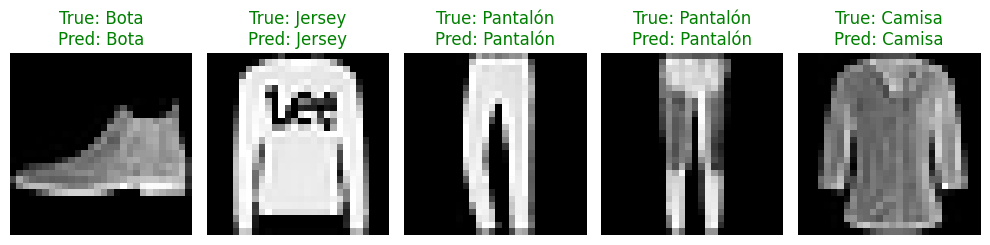

In [26]:
# B.3 — Predice y visualiza las primeras 5 imágenes
import matplotlib.pyplot as plt
import numpy as np

# Hacer predicciones en el conjunto de prueba
predictions = model.predict(x_test)

# Tu código aquí — muestra 5 imágenes con su predicción
# Pide a Gemini: "Muestra las primeras 5 imágenes del test set con la predicción del modelo"

plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap='gray')
    plt.axis('off')
    true_label = clases[y_test[i]]
    predicted_label = clases[np.argmax(predictions[i])]
    color = "green" if true_label == predicted_label else "red"
    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
plt.tight_layout()
plt.show()

---
## Parte C — Escribe una Spec (Opcional)

Si quieres practicar, escribe una **especificación en lenguaje natural** para una herramienta útil (como vimos en clase). Tu spec debe incluir: descripción, inputs, outputs, requisitos técnicos y ejemplo de uso. Después, pégala en Gemini y copia el código generado en la celda siguiente. Esto no es obligatorio pero es excelente práctica de prompting.

In [ ]:
# C.1 — Tu especificación
spec = """
# Spec: Calcula el área y el perímetro de figuras geométricas

## Descripción
Aplicación de consola que calcula area y perímetro de figuras geométricas
(cuadrado, ciculo, triangulo).

## Inputs
- Tipo de Figura (string, no case sensitive) - Cuadrado, Círculo, Triángulo
- Lado (float)
- Base (float)
- Radio (float)
- Altura (float)

## Outputs
- Area (float, 2 decimales)
- Perimetro (float, 2 decimales)

## Requisitos técnicos
- Python puro, sin librerías externas
- Type hints, docstring Google style
- Validación de inputs con ValueError y mensajes claros
- Validación de petición de datos según tipo de figura

## Ejemplo
Tipo de Figura: Cuadrado
Lado: 2
Base: 2
→ Area: 4
→ Perímetro: 4

Tipo de Figura: Circulo
Radio: 3
→ Area: 28.27
→ Perímetro: 18.85
"""
print(spec)

In [27]:
# C.2 — Código generado por Gemini a partir de tu spec
import math

def calculate_square(side: float) -> tuple[float, float]:
    """
    Calcula el área y el perímetro de un cuadrado.

    Args:
        side (float): La longitud de un lado del cuadrado.

    Returns:
        tuple[float, float]: Una tupla que contiene el área y el perímetro.

    Raises:
        ValueError: Si el lado no es un número positivo.
    """
    if not isinstance(side, (int, float)) or side <= 0:
        raise ValueError("El lado debe ser un número positivo.")
    area = side * side
    perimeter = 4 * side
    return area, perimeter

def calculate_circle(radius: float) -> tuple[float, float]:
    """
    Calcula el área y el perímetro de un círculo.

    Args:
        radius (float): El radio del círculo.

    Returns:
        tuple[float, float]: Una tupla que contiene el área y el perímetro.

    Raises:
        ValueError: Si el radio no es un número positivo.
    """
    if not isinstance(radius, (int, float)) or radius <= 0:
        raise ValueError("El radio debe ser un número positivo.")
    area = math.pi * radius * radius
    perimeter = 2 * math.pi * radius
    return area, perimeter

def calculate_triangle(base: float, height: float) -> tuple[float, float]:
    """
    Calcula el área y el perímetro de un triángulo.
    Para el cálculo del perímetro, se asume que la base y la altura son los catetos
    de un triángulo rectángulo.

    Args:
        base (float): La longitud de la base del triángulo.
        height (float): La altura del triángulo.

    Returns:
        tuple[float, float]: Una tupla que contiene el área y el perímetro.

    Raises:
        ValueError: Si la base o la altura no son números positivos.
    """
    if not isinstance(base, (int, float)) or base <= 0:
        raise ValueError("La base debe ser un número positivo.")
    if not isinstance(height, (int, float)) or height <= 0:
        raise ValueError("La altura debe ser un número positivo.")

    area = 0.5 * base * height
    hypotenuse = math.sqrt(base**2 + height**2)
    perimeter = base + height + hypotenuse
    return area, perimeter

def run_geometric_calculator():
    """
    Función principal para la aplicación de consola de cálculo de figuras geométricas.
    Solicita al usuario el tipo de figura y sus dimensiones, y luego calcula
    el área y el perímetro, mostrando los resultados.
    """
    print("--- Calculadora de Área y Perímetro de Figuras Geométricas ---")
    while True:
        figure_type_input = input("Introduce el tipo de figura (Cuadrado, Círculo, Triángulo) o 'salir' para terminar: ").strip().lower()

        if figure_type_input == 'salir':
            print("¡Gracias por usar la calculadora!")
            break

        area, perimeter = None, None
        try:
            if figure_type_input == "cuadrado":
                side_str = input("Introduce la longitud del lado: ").strip()
                side = float(side_str)
                area, perimeter = calculate_square(side)
            elif figure_type_input == "circulo" or figure_type_input == "círculo":
                radius_str = input("Introduce el radio: ").strip()
                radius = float(radius_str)
                area, perimeter = calculate_circle(radius)
            elif figure_type_input == "triangulo" or figure_type_input == "triángulo":
                base_str = input("Introduce la longitud de la base: ").strip()
                height_str = input("Introduce la altura: ").strip()
                base = float(base_str)
                height = float(height_str)
                area, perimeter = calculate_triangle(base, height)
            else:
                raise ValueError("Tipo de figura no reconocido. Por favor, elige entre Cuadrado, Círculo o Triángulo.")

            print(f"→ Área: {area:.2f}")
            print(f"→ Perímetro: {perimeter:.2f}")

        except ValueError as e:
            print(f"Error en la entrada: {e}")
        except Exception as e:
            print(f"Ha ocurrido un error inesperado: {e}")
        print("-" * 50)

if __name__ == "__main__":
    run_geometric_calculator()

--- Calculadora de Área y Perímetro de Figuras Geométricas ---
Introduce el tipo de figura (Cuadrado, Círculo, Triángulo) o 'salir' para terminar: Cu
Error en la entrada: Tipo de figura no reconocido. Por favor, elige entre Cuadrado, Círculo o Triángulo.
--------------------------------------------------
Introduce el tipo de figura (Cuadrado, Círculo, Triángulo) o 'salir' para terminar: Cuadrado
Introduce la longitud del lado: 2
→ Área: 4.00
→ Perímetro: 8.00
--------------------------------------------------
Introduce el tipo de figura (Cuadrado, Círculo, Triángulo) o 'salir' para terminar: circulo
Introduce el radio: 3
→ Área: 28.27
→ Perímetro: 18.85
--------------------------------------------------
Introduce el tipo de figura (Cuadrado, Círculo, Triángulo) o 'salir' para terminar: triangulo
Introduce la longitud de la base: 2
Introduce la altura: 3
→ Área: 3.00
→ Perímetro: 8.61
--------------------------------------------------
Introduce el tipo de figura (Cuadrado, Círculo, Triá

---
## 📋 Responde en Blackboard

Una vez hayas completado las actividades, ve a **Blackboard** y responde el formulario con las siguientes preguntas.

---

### Pregunta 1 (***Verdadero*** / Falso)

**Un array de NumPy solo puede contener elementos del mismo tipo de dato (por ejemplo, todos enteros o todos floats).**

---

### Pregunta 2 (Multirespuesta)

**¿Qué método de Pandas se usa para agrupar datos y calcular agregaciones (por ejemplo, media por categoría)?**

- a) `merge()`
- ***b) `groupby()`***
- c) `pivot()`
- d) `sort_values()`

---

### Pregunta 3 (Verdadero / ***Falso***)

**En el dataset de ventas del ejercicio (Parte A), el producto con mayor ingreso total es el "Monitor".**
R. Laptop
---

### Pregunta 4 (Multirespuesta)

**En Keras, ¿qué función de activación se usa típicamente en la capa de salida para clasificación multiclase (10 categorías)?**

- a) relu
- b) sigmoid
- ***c) softmax***
- d) tanh

---

### Pregunta 5 (***Verdadero*** / Falso)

**La técnica de prompting "Chain of Thought" consiste en pedirle al modelo que razone paso a paso antes de dar la respuesta final.**

---

### Pregunta 6 (Multirespuesta)

**¿Qué hace la capa `Flatten` en un modelo Keras para clasificar imágenes de Fashion-MNIST (28×28)?**

- a) Normaliza los píxeles entre 0 y 1
- b) Aplica una convolución para detectar bordes
- ***c) Convierte la imagen 28×28 en un vector de 784 elementos***
- d) Reduce las dimensiones usando PCA

---

### Pregunta 7 (***Verdadero*** / Falso)

**Fashion-MNIST contiene imágenes de 28×28 píxeles en escala de grises.**

---

### Pregunta 8 (Multirespuesta)

**¿Qué función de pérdida (loss) se usa para clasificación multiclase con etiquetas enteras en Keras?**

- a) `binary_crossentropy`
- b) `mean_squared_error`
- ***c) `sparse_categorical_crossentropy`***
- d) `hinge`